In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("cleaned_retail_sales.csv")

print("Cleaned dataset loaded successfully.")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\nColumn list:")
print(df.columns.tolist())

Cleaned dataset loaded successfully.
Total rows: 11971
Total columns: 14

Column list:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied', 'Day of Week', 'Month', 'Year']


In [4]:
# Question 1: Revenue by Category
category_revenue = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
print("Total Revenue by Category:")
print(category_revenue)

Total Revenue by Category:
Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total Spent, dtype: float64


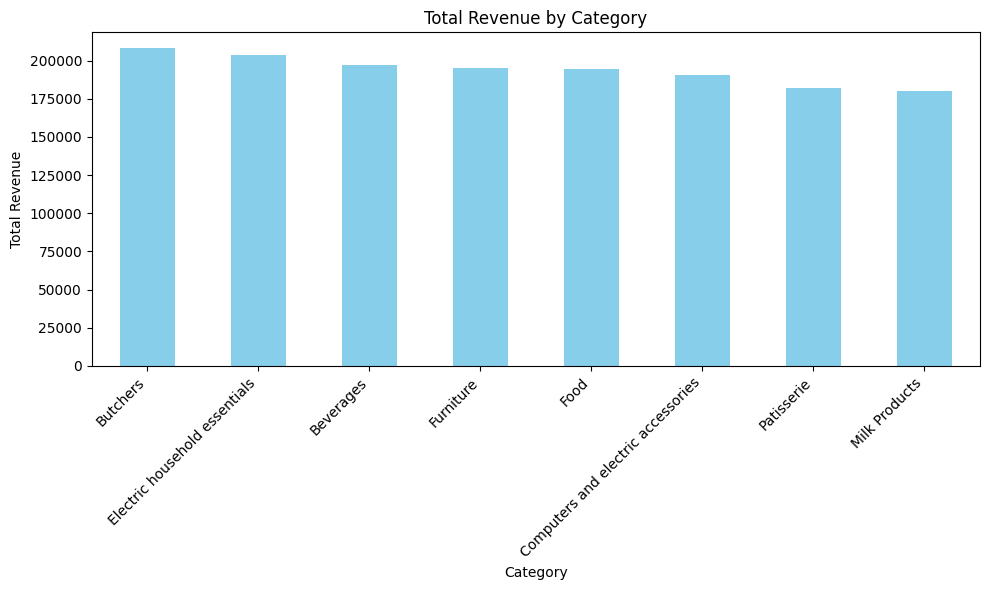

In [5]:
# Bar chart: Revenue by Category

plt.figure(figsize=(10, 6))
category_revenue.plot(kind='bar', color='skyblue')

plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [6]:
# Question 2: Sales by Day of Week

day_revenue = df.groupby('Day of Week')['Total Spent'].sum()

print("Total Revenue by Day of Week:")
print(day_revenue)

Total Revenue by Day of Week:
Day of Week
Friday       232786.0
Monday       213090.5
Saturday     224191.0
Sunday       225991.0
Thursday     219380.5
Tuesday      219650.0
Wednesday    216982.0
Name: Total Spent, dtype: float64


In [7]:
# Reorder days in correct weekly sequence (Monday to Sunday)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_revenue = day_revenue.reindex(day_order)

print("Total Revenue by Day of Week (correct order):")
print(day_revenue)

Total Revenue by Day of Week (correct order):
Day of Week
Monday       213090.5
Tuesday      219650.0
Wednesday    216982.0
Thursday     219380.5
Friday       232786.0
Saturday     224191.0
Sunday       225991.0
Name: Total Spent, dtype: float64


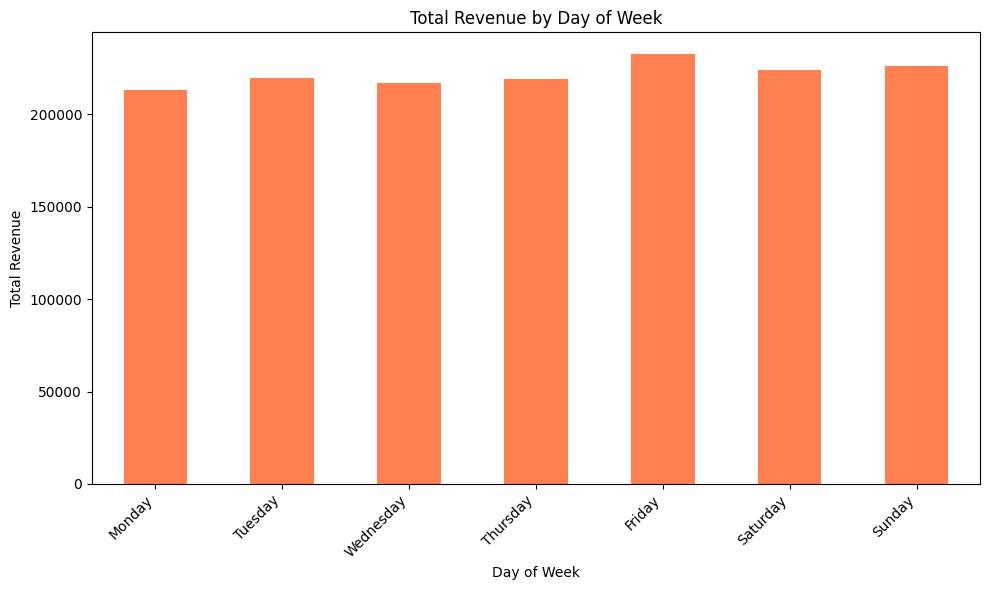

In [8]:
# Bar chart: Revenue by Day of Week

plt.figure(figsize=(10, 6))
day_revenue.plot(kind='bar', color='coral')

plt.title('Total Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [9]:
# Question 3: Transaction Count by Payment Method

payment_counts = df['Payment Method'].value_counts()

print("Transaction Count by Payment Method:")
print(payment_counts)

Transaction Count by Payment Method:
Payment Method
Cash              4103
Digital Wallet    3941
Credit Card       3927
Name: count, dtype: int64


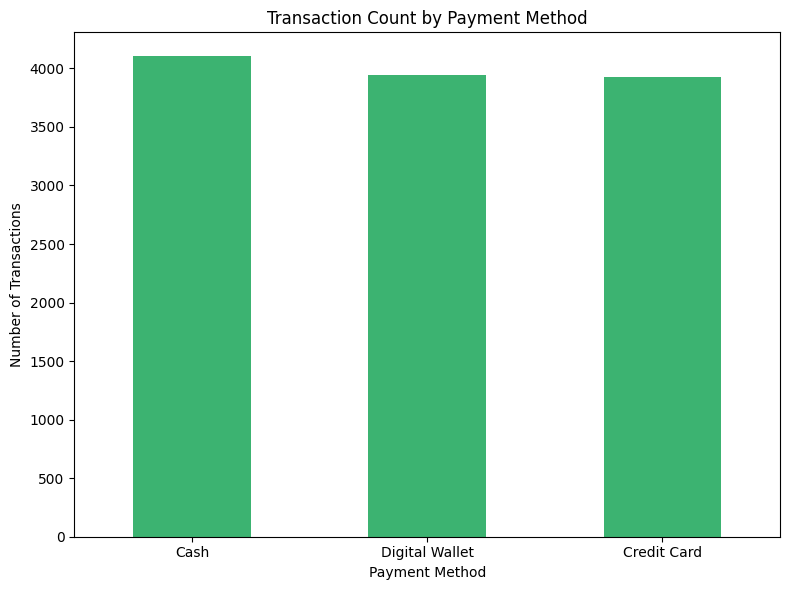

In [10]:
# Bar chart: Transaction Count by Payment Method

plt.figure(figsize=(8, 6))
payment_counts.plot(kind='bar', color='mediumseagreen')

plt.title('Transaction Count by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [11]:
# Payment Method breakdown by Category

payment_by_category = df.groupby(['Category', 'Payment Method']).size().unstack()

print("Transaction Count: Category vs Payment Method")
print(payment_by_category)

Transaction Count: Category vs Payment Method
Payment Method                      Cash  Credit Card  Digital Wallet
Category                                                             
Beverages                            554          457             485
Butchers                             495          528             473
Computers and electric accessories   521          490             466
Electric household essentials        518          466             532
Food                                 528          482             497
Furniture                            509          506             510
Milk Products                        497          519             497
Patisserie                           481          479             481


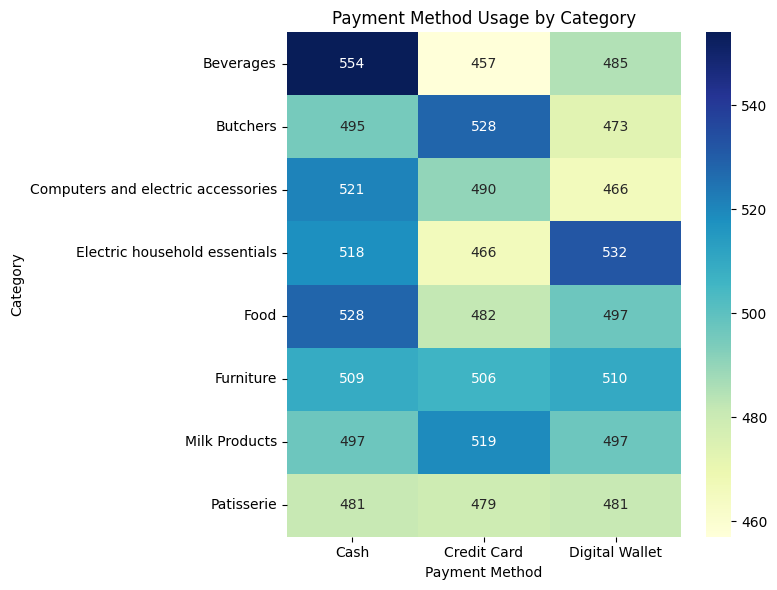

In [12]:
# Heatmap: Payment Method distribution across Categories

plt.figure(figsize=(8, 6))
sns.heatmap(payment_by_category, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Payment Method Usage by Category')
plt.xlabel('Payment Method')
plt.ylabel('Category')
plt.tight_layout()

plt.show()

In [13]:
# Question 4: Revenue by Month

month_revenue = df.groupby('Month')['Total Spent'].sum()

print("Total Revenue by Month:")
print(month_revenue)

Total Revenue by Month:
Month
April        125618.5
August       123287.5
December     129688.5
February     119685.0
January      174421.0
July         131509.0
June         129771.0
March        122392.0
May          124594.5
November     122346.5
October      119413.5
September    129344.0
Name: Total Spent, dtype: float64


In [14]:
# Reorder months in correct calendar sequence (January to December)

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

month_revenue = month_revenue.reindex(month_order)

print("Total Revenue by Month (correct order):")
print(month_revenue)

Total Revenue by Month (correct order):
Month
January      174421.0
February     119685.0
March        122392.0
April        125618.5
May          124594.5
June         129771.0
July         131509.0
August       123287.5
September    129344.0
October      119413.5
November     122346.5
December     129688.5
Name: Total Spent, dtype: float64


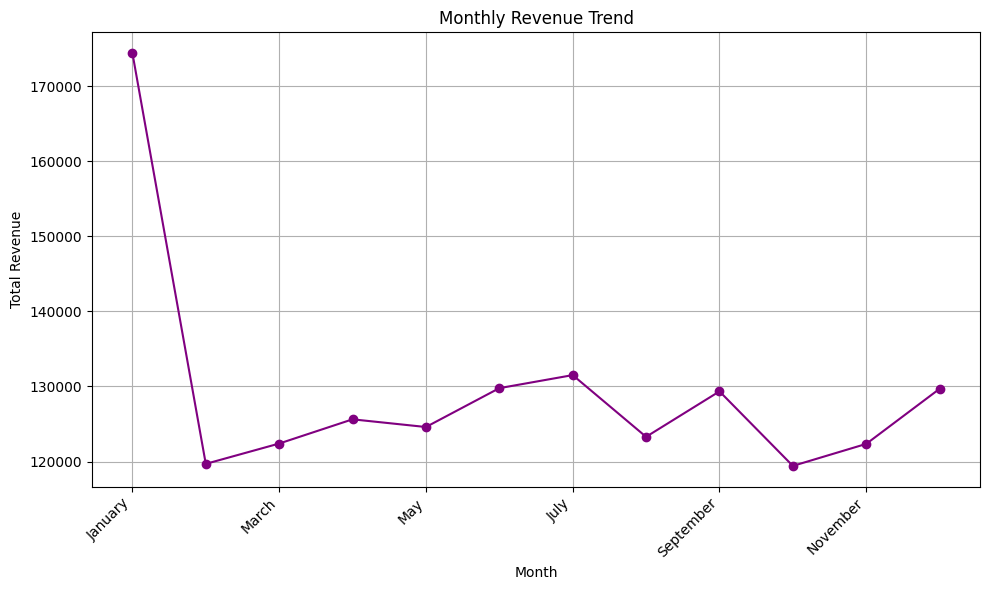

In [15]:
# Line chart: Monthly Revenue Trend

plt.figure(figsize=(10, 6))
month_revenue.plot(kind='line', marker='o', color='purple')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()

plt.show()

In [16]:
# Investigate: is January's spike due to more transactions, or is it a real trend?

month_transaction_count = df.groupby('Month')['Transaction ID'].count().reindex(month_order)

print("Transaction Count by Month:")
print(month_transaction_count)

Transaction Count by Month:
Month
January      1295
February      916
March         965
April         953
May           978
June          991
July         1039
August        992
September     984
October       934
November      950
December      974
Name: Transaction ID, dtype: int64


In [17]:
# Check average transaction value by month

avg_transaction_value = df.groupby('Month')['Total Spent'].mean().reindex(month_order)

print("Average Transaction Value by Month:")
print(avg_transaction_value)

Average Transaction Value by Month:
Month
January      134.688031
February     130.660480
March        126.831088
April        131.813746
May          127.397239
June         130.949546
July         126.572666
August       124.281754
September    131.447154
October      127.851713
November     128.785789
December     133.150411
Name: Total Spent, dtype: float64


In [18]:
# Question 5: Average Transaction Value by Location

location_avg = df.groupby('Location')['Total Spent'].mean().sort_values(ascending=False)

print("Average Transaction Value by Location:")
print(location_avg)

Average Transaction Value by Location:
Location
Online      130.422050
In-store    128.861596
Name: Total Spent, dtype: float64


In [19]:
# Also check transaction count by Location for context

location_count = df['Location'].value_counts()

print("Transaction Count by Location:")
print(location_count)

Transaction Count by Location:
Location
Online      6068
In-store    5903
Name: count, dtype: int64


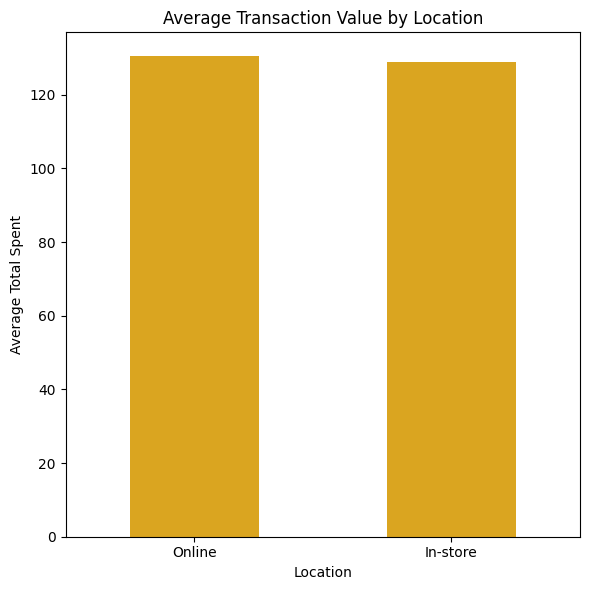

In [20]:
# Bar chart: Average Transaction Value by Location

plt.figure(figsize=(6, 6))
location_avg.plot(kind='bar', color='goldenrod')

plt.title('Average Transaction Value by Location')
plt.xlabel('Location')
plt.ylabel('Average Total Spent')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [21]:
# Question 6a: Top 10 items by Quantity sold

top_items_by_quantity = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

print("Top 10 Items by Quantity Sold:")
print(top_items_by_quantity)

Top 10 Items by Quantity Sold:
Item
Item_2_BEV      693
Item_16_MILK    664
Item_19_MILK    639
Item_14_FOOD    628
Item_13_FOOD    628
Item_5_FUR      625
Item_25_FUR     625
Item_25_EHE     622
Item_1_MILK     622
Item_19_CEA     603
Name: Quantity, dtype: int64


In [22]:
# Question 6b: Top 10 items by Revenue generated

top_items_by_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10)

print("Top 10 Items by Revenue:")
print(top_items_by_revenue)

Top 10 Items by Revenue:
Item
Item_25_FUR     25625.0
Item_25_EHE     25502.0
Item_25_BUT     22427.0
Item_24_FUR     22080.5
Item_25_FOOD    21771.0
Item_22_BUT     21462.0
Item_23_BUT     20596.0
Item_19_MILK    20448.0
Item_23_EHE     20178.0
Item_23_PAT     19684.0
Name: Total Spent, dtype: float64


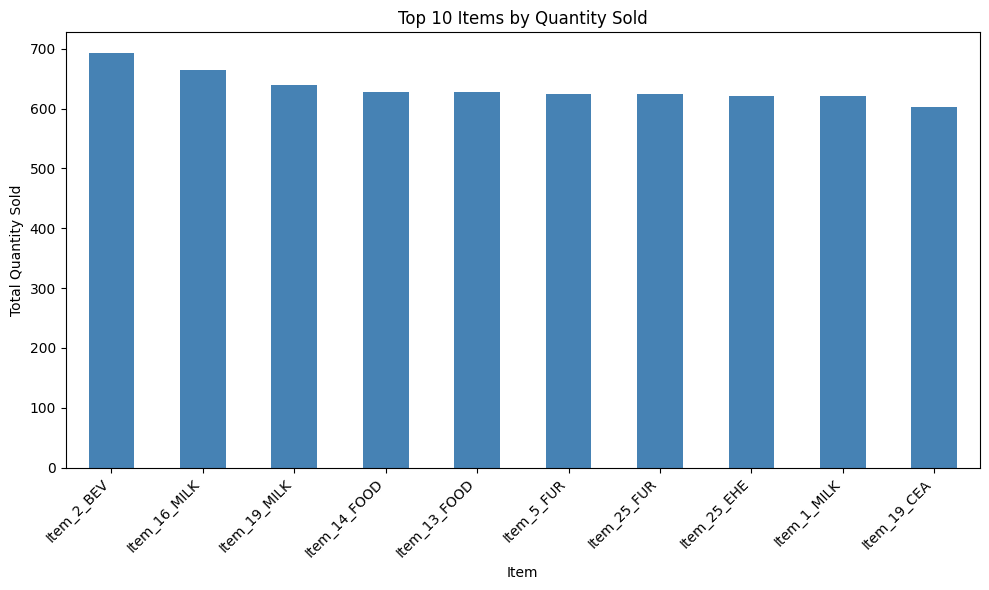

In [23]:
# Bar chart: Top 10 Items by Quantity Sold

plt.figure(figsize=(10, 6))
top_items_by_quantity.plot(kind='bar', color='steelblue')

plt.title('Top 10 Items by Quantity Sold')
plt.xlabel('Item')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

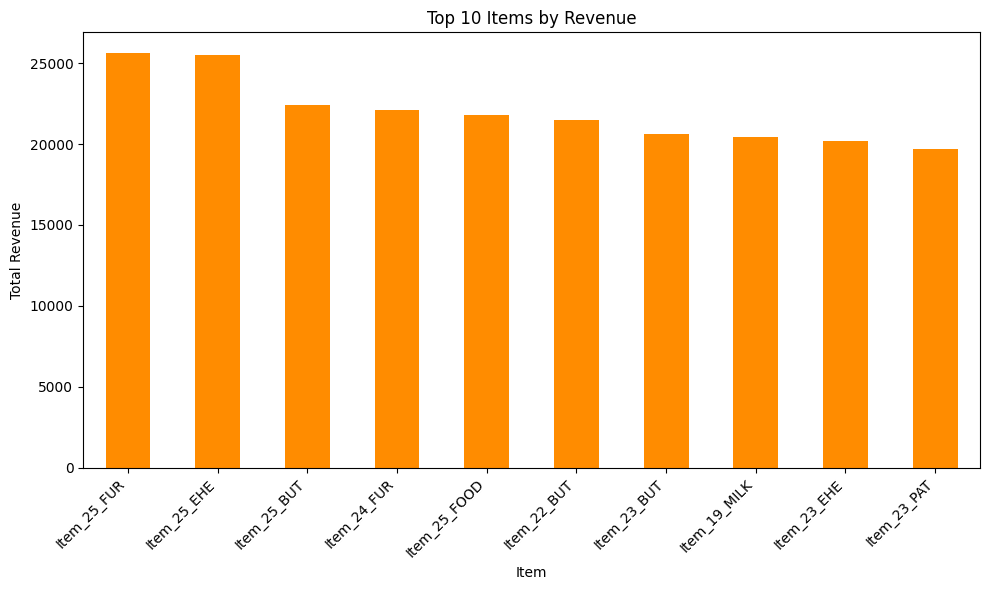

In [24]:
# Bar chart: Top 10 Items by Revenue

plt.figure(figsize=(10, 6))
top_items_by_revenue.plot(kind='bar', color='darkorange')

plt.title('Top 10 Items by Revenue')
plt.xlabel('Item')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [26]:
# Question 7: Check if missing values had any pattern (using original raw data)

df_raw = pd.read_csv("retail_store_sales.csv")

missing_by_category = df_raw[df_raw['Item'].isnull()]['Category'].value_counts()

print("Missing 'Item' values by Category:")
print(missing_by_category)

Missing 'Item' values by Category:
Category
Food                                  162
Computers and electric accessories    161
Patisserie                            159
Milk Products                         159
Electric household essentials         154
Butchers                              147
Beverages                             140
Furniture                             131
Name: count, dtype: int64


In [27]:
# Convert to percentage of each category's total rows

category_totals = df_raw['Category'].value_counts()

missing_percentage = (missing_by_category / category_totals * 100).sort_values(ascending=False)

print("Missing 'Item' % by Category:")
print(missing_percentage.round(2))

Missing 'Item' % by Category:
Category
Patisserie                            10.41
Computers and electric accessories    10.33
Food                                  10.20
Milk Products                         10.04
Electric household essentials          9.68
Butchers                               9.38
Beverages                              8.93
Furniture                              8.23
Name: count, dtype: float64


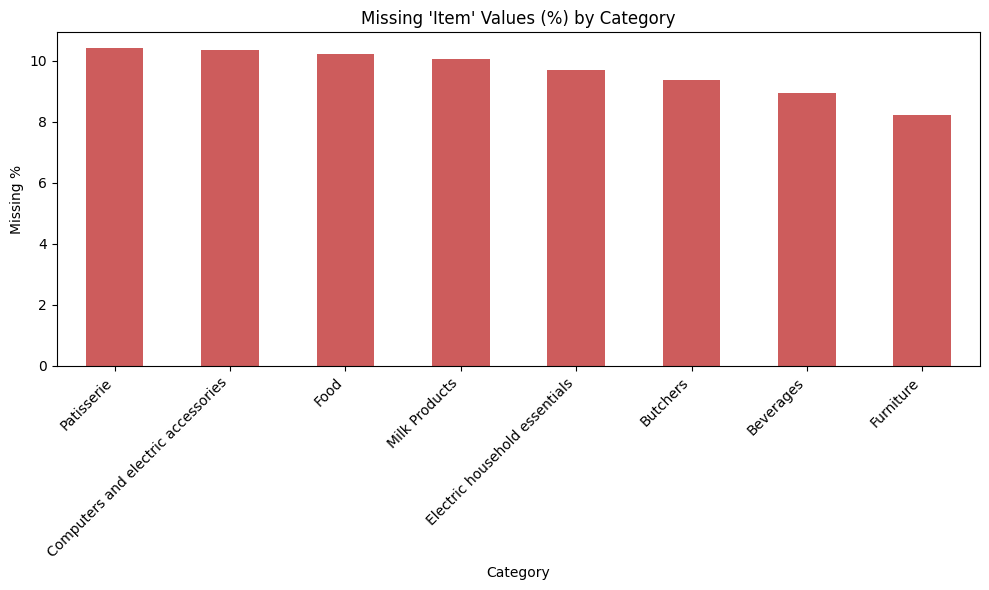

In [28]:
# Bar chart: Missing 'Item' % by Category

plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar', color='indianred')

plt.title("Missing 'Item' Values (%) by Category")
plt.xlabel('Category')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()